In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.neighbors     import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing   import StandardScaler

# (i)  LOAD DATASET
df = pd.read_csv('healthcare200.csv')
print(f"  Shape  : {df.shape}")
print(f"  Columns: {list(df.columns)}")
print("\n  First 10 rows:")
print(df.head(10).to_string(index=False))
print("\n  Statistical Summary:")
print(df.describe().round(2))


# Split into features X and target y
X = df.drop(columns=['visit_cost'])
y = df['visit_cost']
all_features = list(X.columns)
print(f"\n  All Features ({len(all_features)}): {all_features}")
print(f"  Target: visit_cost")


# Scale features (important for kNN)
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=all_features)


#  HELPER : get cross-validated R² score for a feature subset
def get_score(model, feature_list, X_data, y_data):
    scores = cross_val_score(model, X_data[feature_list], y_data,
                             cv=5, scoring='r2')
    return round(scores.mean(), 4)

  Shape  : (200, 13)
  Columns: ['age', 'bmi', 'blood_pressure', 'sugar_level', 'cholesterol', 'heart_rate', 'height_cm', 'weight_kg', 'exercise_hrs', 'sleep_hrs', 'smoking', 'alcohol', 'visit_cost']

  First 10 rows:
 age  bmi  blood_pressure  sugar_level  cholesterol  heart_rate  height_cm  weight_kg  exercise_hrs  sleep_hrs  smoking  alcohol  visit_cost
  58 31.2             108          130          191          85        166        100           9.5        4.7        1        1        4346
  71 33.3             147          196          250         105        186        107           9.1        7.9        1        0        6061
  48 37.4             144          174          155          95        174         90           7.2        8.6        1        0        4576
  34 31.7             179           70          175          82        187         55           7.5        9.6        1        0        4040
  62 24.5             179          161          213          60        161   

In [7]:
# (ii)  FORWARD FEATURE SELECTION
def forward_selection(model, model_name, X_data, y_data):
    print(f"  FORWARD FEATURE SELECTION  — {model_name}")
    

    remaining  = list(X_data.columns)  
    selected   = []                      
    best_scores = []                     
    print(f"\n  {'Step':<6} {'Added Feature':<20} {'R² Score'}")
    print("  " + "-" * 42)

    while remaining:
        scores = {}
        for feat in remaining:
            candidate = selected + [feat]
            scores[feat] = get_score(model, candidate, X_data, y_data)

        # pick the feature with the highest score
        best_feat  = max(scores, key=scores.get)
        best_score = scores[best_feat]

        # Only add if it improves the score
        if best_scores and best_score <= best_scores[-1]:
            break

        selected.append(best_feat)
        remaining.remove(best_feat)
        best_scores.append(best_score)

        print(f"  {len(selected):<6} {best_feat:<20} {best_score}")

    print(f"\n   Selected Features ({len(selected)}): {selected}")
    print(f"   Final R² Score : {best_scores[-1]}")
    return selected, best_scores


# Run Forward Selection for both models
lr_model  = LinearRegression()
knn_model = KNeighborsRegressor(n_neighbors=5)

ffs_lr_feats,  ffs_lr_scores  = forward_selection(lr_model,  "Linear Regression", X_scaled, y)
print()
ffs_knn_feats, ffs_knn_scores = forward_selection(knn_model, "kNN Regressor",     X_scaled, y)

  FORWARD FEATURE SELECTION  — Linear Regression

  Step   Added Feature        R² Score
  ------------------------------------------
  1      cholesterol          0.2546
  2      age                  0.5069
  3      blood_pressure       0.7359
  4      sugar_level          0.8398
  5      bmi                  0.8751
  6      weight_kg            0.8753

   Selected Features (6): ['cholesterol', 'age', 'blood_pressure', 'sugar_level', 'bmi', 'weight_kg']
   Final R² Score : 0.8753

  FORWARD FEATURE SELECTION  — kNN Regressor

  Step   Added Feature        R² Score
  ------------------------------------------
  1      cholesterol          0.129
  2      age                  0.4772
  3      blood_pressure       0.6572
  4      sugar_level          0.7456
  5      bmi                  0.7539

   Selected Features (5): ['cholesterol', 'age', 'blood_pressure', 'sugar_level', 'bmi']
   Final R² Score : 0.7539


In [6]:
# (iii)  BACKWARD FEATURE ELIMINATION

def backward_elimination(model, model_name, X_data, y_data):
    print(f"  BACKWARD FEATURE ELIMINATION  — {model_name}")
    

    remaining   = list(X_data.columns)   # start with all features
    best_scores = []

    # baseline score with all features
    baseline = get_score(model, remaining, X_data, y_data)
    best_scores.append(baseline)

    print(f"\n  Baseline score (all features): {baseline}")
    print(f"\n  {'Step':<6} {'Removed Feature':<22} {'R² Score'}")
    print("  " + "-" * 44)

    step = 1
    while len(remaining) > 1:
        scores = {}
        for feat in remaining:
            candidate = [f for f in remaining if f != feat]
            scores[feat] = get_score(model, candidate, X_data, y_data)

        # Remove feature whose removal causes LEAST drop (or best gain)
        worst_feat  = max(scores, key=scores.get)
        new_score   = scores[worst_feat]

        # Stop if removing hurts score noticeably
        if new_score < best_scores[-1] - 0.01:
            break

        remaining.remove(worst_feat)
        best_scores.append(new_score)

        print(f"  {step:<6} {worst_feat:<22} {new_score}")
        step += 1

    print(f"\n   Remaining Features ({len(remaining)}): {remaining}")
    print(f"   Final R² Score : {best_scores[-1]}")
    return remaining, best_scores


# Run Backward Elimination for both models
bfe_lr_feats,  bfe_lr_scores  = backward_elimination(lr_model,  "Linear Regression", X_scaled, y)
print()
bfe_knn_feats, bfe_knn_scores = backward_elimination(knn_model, "kNN Regressor",     X_scaled, y)

  BACKWARD FEATURE ELIMINATION  — Linear Regression

  Baseline score (all features): 0.8676

  Step   Removed Feature        R² Score
  --------------------------------------------
  1      exercise_hrs           0.8713
  2      sleep_hrs              0.8728
  3      heart_rate             0.8743
  4      height_cm              0.875
  5      weight_kg              0.8752
  6      smoking                0.8753
  7      alcohol                0.8751

   Remaining Features (5): ['age', 'bmi', 'blood_pressure', 'sugar_level', 'cholesterol']
   Final R² Score : 0.8751

  BACKWARD FEATURE ELIMINATION  — kNN Regressor

  Baseline score (all features): 0.5529

  Step   Removed Feature        R² Score
  --------------------------------------------
  1      sleep_hrs              0.6037
  2      heart_rate             0.6478
  3      smoking                0.6674
  4      weight_kg              0.6909
  5      height_cm              0.6917
  6      exercise_hrs           0.7076
  7      alcoho

In [12]:
# (iv)  COMPARISON — FFS vs BFE for both models
print("  (iv) COMPARISON: FFS vs BFE")
def compare(model_name, ffs_feats, ffs_scores, bfe_feats, bfe_scores):
    print(f"\n  ── {model_name} ──")
    print(f"  FFS selected  ({len(ffs_feats)} features): {ffs_feats}\n")
    print(f"  BFE remaining ({len(bfe_feats)} features): {bfe_feats}")
    common = set(ffs_feats) & set(bfe_feats)
    print(f"  Common features  ({len(common)}): {sorted(common)}")
    print(f"  FFS Final R²  : {ffs_scores[-1]}\n")
    print(f"  BFE Final R²  : {bfe_scores[-1]}")

compare("Linear Regression", ffs_lr_feats,  ffs_lr_scores,  bfe_lr_feats,  bfe_lr_scores)
print()
compare("kNN Regressor",     ffs_knn_feats, ffs_knn_scores, bfe_knn_feats, bfe_knn_scores)

  (iv) COMPARISON: FFS vs BFE

  ── Linear Regression ──
  FFS selected  (6 features): ['cholesterol', 'age', 'blood_pressure', 'sugar_level', 'bmi', 'weight_kg']

  BFE remaining (5 features): ['age', 'bmi', 'blood_pressure', 'sugar_level', 'cholesterol']
  Common features  (5): ['age', 'blood_pressure', 'bmi', 'cholesterol', 'sugar_level']
  FFS Final R²  : 0.8753

  BFE Final R²  : 0.8751


  ── kNN Regressor ──
  FFS selected  (5 features): ['cholesterol', 'age', 'blood_pressure', 'sugar_level', 'bmi']

  BFE remaining (4 features): ['age', 'blood_pressure', 'sugar_level', 'cholesterol']
  Common features  (4): ['age', 'blood_pressure', 'cholesterol', 'sugar_level']
  FFS Final R²  : 0.7539

  BFE Final R²  : 0.7456


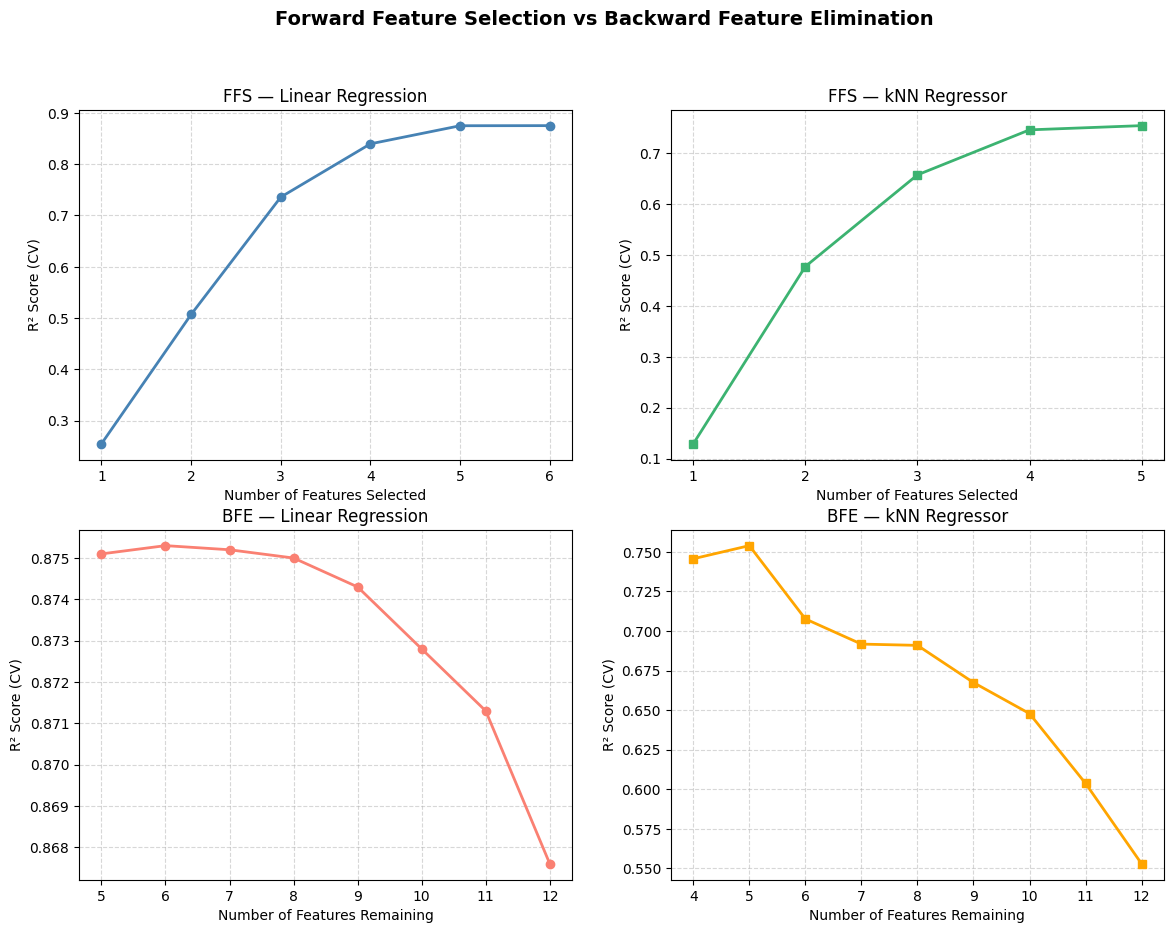

In [13]:
#  PLOTS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Forward Feature Selection vs Backward Feature Elimination',
             fontsize=14, fontweight='bold')

#Plot 1: FFS - Linear Regression 
axes[0, 0].plot(range(1, len(ffs_lr_scores)+1), ffs_lr_scores,
                marker='o', color='steelblue', linewidth=2)
axes[0, 0].set_title('FFS — Linear Regression')
axes[0, 0].set_xlabel('Number of Features Selected')
axes[0, 0].set_ylabel('R² Score (CV)')
axes[0, 0].set_xticks(range(1, len(ffs_lr_scores)+1))
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

#Plot 2: FFS - kNN 
axes[0, 1].plot(range(1, len(ffs_knn_scores)+1), ffs_knn_scores,
                marker='s', color='mediumseagreen', linewidth=2)
axes[0, 1].set_title('FFS — kNN Regressor')
axes[0, 1].set_xlabel('Number of Features Selected')
axes[0, 1].set_ylabel('R² Score (CV)')
axes[0, 1].set_xticks(range(1, len(ffs_knn_scores)+1))
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

#Plot 3: BFE - Linear Regression
n_bfe_lr = len(bfe_lr_scores)
axes[1, 0].plot(range(len(all_features), len(all_features)-n_bfe_lr, -1),
                bfe_lr_scores,
                marker='o', color='salmon', linewidth=2)
axes[1, 0].set_title('BFE — Linear Regression')
axes[1, 0].set_xlabel('Number of Features Remaining')
axes[1, 0].set_ylabel('R² Score (CV)')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 4: BFE - kNN ---
n_bfe_knn = len(bfe_knn_scores)
axes[1, 1].plot(range(len(all_features), len(all_features)-n_bfe_knn, -1),
                bfe_knn_scores,
                marker='s', color='orange', linewidth=2)
axes[1, 1].set_title('BFE — kNN Regressor')
axes[1, 1].set_xlabel('Number of Features Remaining')
axes[1, 1].set_ylabel('R² Score (CV)')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

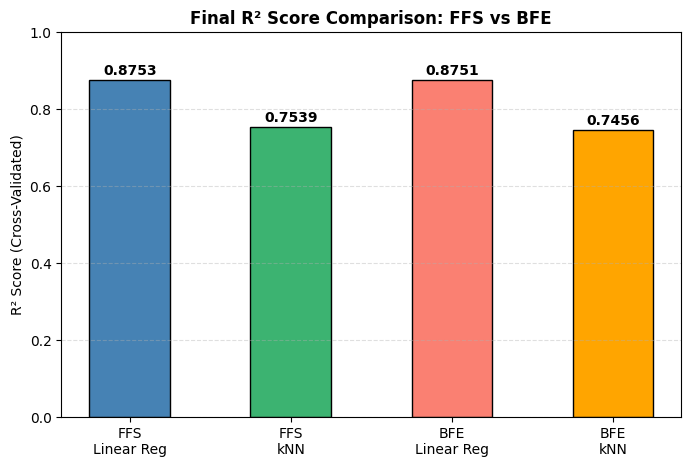

In [14]:
#Bar chart: Final R² comparison
fig2, ax = plt.subplots(figsize=(8, 5))

methods = ['FFS\nLinear Reg', 'FFS\nkNN', 'BFE\nLinear Reg', 'BFE\nkNN']
scores  = [ffs_lr_scores[-1], ffs_knn_scores[-1],
           bfe_lr_scores[-1], bfe_knn_scores[-1]]
colors  = ['steelblue', 'mediumseagreen', 'salmon', 'orange']

bars = ax.bar(methods, scores, color=colors, edgecolor='black', width=0.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            str(score), ha='center', va='bottom', fontweight='bold')

ax.set_title('Final R² Score Comparison: FFS vs BFE', fontweight='bold')
ax.set_ylabel('R² Score (Cross-Validated)')
ax.set_ylim(0, 1)
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', linestyle='--', alpha=0.4)